In [ ]:
import mlflow
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_percentage_error, root_mean_squared_error
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import datetime
from pathlib import Path

In [ ]:
mlflow.set_tracking_uri("sqlite:///mlflow38.db")  # log runs to a SQLite DB; this is also what `mlflow ui` reads by default
mlflow.set_experiment("xgb_car_price") # you want to keep track of experiments - every project as an experiment 

2026/09/01 07:02:18 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/09/01 07:02:18 INFO mlflow.store.db.utils: Updating database tables
2026/09/01 07:02:18 INFO alembic.runtime.migration: Context impl SQLiteImpl.
2026/09/01 07:02:18 INFO alembic.runtime.migration: Will assume non-transactional DDL.
2026/09/01 07:02:18 INFO alembic.runtime.migration: Context impl SQLiteImpl.
2026/09/01 07:02:18 INFO alembic.runtime.migration: Will assume non-transactional DDL.


<Experiment: artifact_location='file:C:/Users/swath/mlops_scaler/model_tracking/mlruns/1', creation_time=1788187098411, experiment_id='1', last_update_time=1788187098411, lifecycle_stage='active', name='xgb_car_price', tags={}>

In [4]:
mlflow.enable_system_metrics_logging()

In [5]:
# the CSV lives in the repo's data/ folder, one level up from this notebook
DATA_PATH = Path("..") / "data" / "cars24-car-price-cleaned-new.csv"
cars_df = pd.read_csv(DATA_PATH)


In [6]:
cars_df

,selling_price,km_driven,mileage,engine,max_power,age,make,model,Individual,Trustmark Dealer,Diesel,Electric,LPG,Petrol,Manual,5,>5
0,1.20,120000,19.70,796.0,46.30,11.0,MARUTI,ALTO STD,1,0,0,0,0,1,1,1,0
1,5.50,20000,18.90,1197.0,82.00,7.0,HYUNDAI,GRAND I10 ASTA,1,0,0,0,0,1,1,1,0
2,2.15,60000,17.00,1197.0,80.00,13.0,HYUNDAI,I20 ASTA,1,0,0,0,0,1,1,1,0
3,2.26,37000,20.92,998.0,67.10,11.0,MARUTI,ALTO K10 2010-2014 VXI,1,0,0,0,0,1,1,1,0
4,5.70,30000,22.77,1498.0,98.59,8.0,FORD,ECOSPORT 2015-2021 1.5 TDCI TITANIUM BSIV,0,0,1,0,0,0,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19815,6.50,69480,23.59,1364.0,67.05,6.0,TOYOTA,PLATINUM ETIOS 1.4 GXD,0,0,1,0,0,0,1,1,0
19816,9.25,18000,17.50,1373.0,91.10,4.0,MARUTI,ERTIGA BSIV VXI,0,0,0,0,0,1,1,0,1
19817,4.25,67000,21.14,1498.0,103.52,8.0,SKODA,RAPID 1.5 TDI ELEGANCE,0,0,1,0,0,0,1,1,0
19818,12.25,3800000,16.00,2179.0,140.00,7.0,MAHINDRA,XUV500 W6 2WD,0,0,1,0,0,0,1,0,1


In [7]:
X = cars_df[['km_driven','mileage','age','Petrol','Diesel','Electric']]
y = cars_df[['selling_price']]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

2026/09/01 07:40:15 INFO mlflow.system_metrics.system_metrics_monitor: Skip logging GPU metrics. Set logger level to DEBUG for more details.
2026/09/01 07:40:15 INFO mlflow.system_metrics.system_metrics_monitor: Started monitoring system metrics.


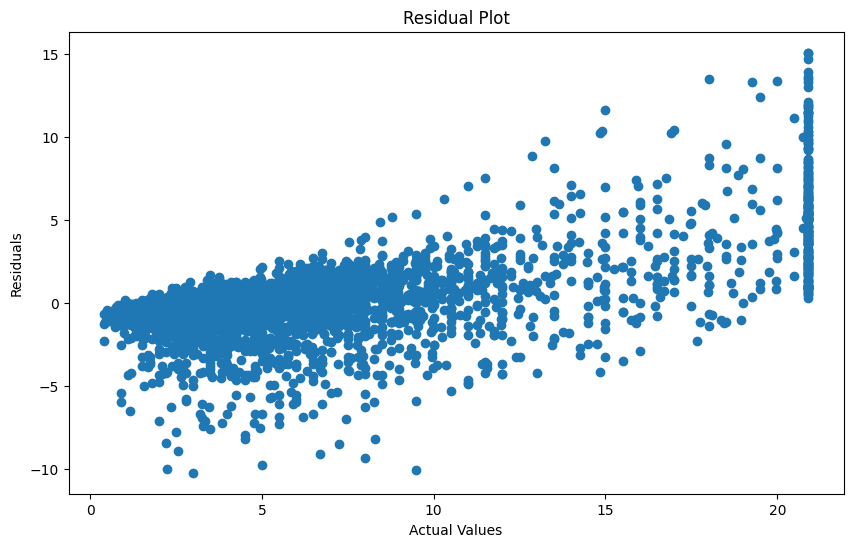

2026/09/01 07:40:16 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/09/01 07:40:23 INFO mlflow.system_metrics.system_metrics_monitor: Stopping system metrics monitoring...
2026/09/01 07:40:23 INFO mlflow.system_metrics.system_metrics_monitor: Successfully terminated system metrics monitoring!


In [11]:
now = datetime.datetime.now()
with mlflow.start_run(run_name=f"inference id {now}") as run:

    n_estimators = 50
    learning_rate = 0.07
    max_depth = 7
    xgb_model = XGBRegressor(
        n_estimators=n_estimators,
        learning_rate=learning_rate,
        max_depth=max_depth
    )

    

    xgb_model.fit(X_train, y_train)
    y_pred = xgb_model.predict(X_test)




    mape = mean_absolute_percentage_error(y_test, y_pred)
    rmse = root_mean_squared_error(y_test, y_pred)

    # log hyperparameters
    mlflow.log_param("max_depth", max_depth)
    mlflow.log_param("learning_rate", learning_rate)
    mlflow.log_param("n_estimators", n_estimators)
    mlflow.log_param("version", "v4.0")
    mlflow.log_param("number of features", len(X.columns))
    # used to log model metrics
    mlflow.log_metric("mape", mape)
    mlflow.log_metric("rmse", rmse)
    mlflow.log_metric("Average selling price", np.mean(y_train))

    residuals = y_test.values.flatten() - y_pred
    plt.figure(figsize=(10, 6))
    plt.scatter(y_test, residuals)
    plt.xlabel("Actual Values")
    plt.ylabel("Residuals")
    plt.title("Residual Plot")
    plt.savefig("residual_plot.png")  # save before show(); show() clears the figure
    plt.show()


    mlflow.log_artifact("residual_plot.png")  # log the residual plot as an artifact
    mlflow.log_artifact(str(DATA_PATH))  # log the dataset as an artifact



    
    mlflow.sklearn.log_model(xgb_model, "model") # you can also log the model using sklearn flavor
